# Understanding Distributions: Skewness, Kurtosis, Quantiles & Key Plots


**Goal:** Build intuition for how data is shaped, spread, and summarized — both numerically and visually.

**Topics:** Quantiles → Skewness → Kurtosis → Boxplot → KDE → Violin Plot → QQ Plot → Cheat Sheet

Let's get started.

In [2]:
# imports
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

df = sns.load_dataset('penguins').dropna()
print(df.shape)
df.head()

(333, 7)


,species,island,bill_length_mm,bill_depth_mm,flipper_length_mm,body_mass_g,sex
0,Adelie,Torgersen,39.1,18.7,181.0,3750.0,Male
1,Adelie,Torgersen,39.5,17.4,186.0,3800.0,Female
2,Adelie,Torgersen,40.3,18.0,195.0,3250.0,Female
4,Adelie,Torgersen,36.7,19.3,193.0,3450.0,Female
5,Adelie,Torgersen,39.3,20.6,190.0,3650.0,Male


## 1. Quantiles (Percentiles & IQR)

**What it is:** A quantile is a cut point that divides your data into portions. The 0.5 quantile
(median) splits data in half; the 0.25 and 0.75 quantiles (quartiles) split it into quarters.

**Why we use it:** Quantiles answer "where does a given value rank?" and let us build robust
measures of spread that ignore extreme outliers — unlike the mean/std.

**How to read it:** The **IQR (Interquartile Range) = Q3 − Q1** covers the middle 50% of your data.
A large IQR means values are spread out; a small IQR means they're tightly clustered.

**Tip:** Don't confuse *quantile* (a value, e.g. "4750g") with *percentile rank* (a position, e.g.
"75th percentile"). Also — `np.percentile` and `df.quantile()` use the same math, just different scales (0–100 vs 0–1).

In [5]:
# compute the quantiles for body_mass_g
q1 = df["body_mass_g"].quantile(0.25)
median = df["body_mass_g"].quantile(0.5)
q3 = df["body_mass_g"].quantile(0.75)
iqr = q3-q1

print(f"Q1 (25%): {q1:.0f}g")
print(f"Median (50%): {median:.0f}g")
print(f"Q3 (75%): {q3:.0f}g")
print(f"IQR: {iqr:.0f}g")


Q1 (25%): 3550g
Median (50%): 4050g
Q3 (75%): 4775g
IQR: 1225g


### Interpretation
Half of all penguins weigh between roughly Q1 and Q3 grams — that's your "typical" range.<br/>
The IQR tells you how spread out the *middle* of the data is, ignoring extreme birds.<br/>
We'll use Q1, Q3, and IQR again shortly to define outliers in the boxplot section.

## 2. Skewness (Asymmetry)

**What it is:** Skewness measures the **left/right balance** of a distribution. A symmetric
distribution (like a bell curve) has skewness ≈ 0. Positive skew = a long tail stretching right;
negative skew = a long tail stretching left.

**Why we use it:** It tells you whether the mean is being pulled away from the median by extreme
values — important for deciding whether to use mean or median, and whether to transform data (e.g. log)
before modeling.

**How to read it:**
- Skew ≈ 0 → roughly symmetric
- Skew > 0.5 → noticeably right-skewed (tail to the right)
- Skew < −0.5 → noticeably left-skewed (tail to the left)

**Tip:** A common mistake is assuming skew always means "bad data." Many real-world quantities
(income, wait times, body mass) are naturally right-skewed — it's often expected, not an error.

In [14]:
# computer skewness of whole body_mass_g and also based on each speices
overall_skew = stats.skew(df["body_mass_g"])
by_species_skew = df.groupby("species")["body_mass_g"].apply(stats.skew)

print(f"Overall skewness: {overall_skew:.2f}")
print("\nSkewness by species:")
print(by_species_skew.round(2))

Overall skewness: 0.47

Skewness by species:
species
Adelie       0.28
Chinstrap    0.24
Gentoo       0.04
Name: body_mass_g, dtype: float64


### Interpretation
The overall skewness is mildly positive — a small right tail, likely because Gentoo penguins are heavier and pull the <br/>
distribution's right side out. Notice how skewness *within* each species is much closer to 0 — the "skew" at <br/>
 the population level is partly a mixing-of-groups effect, not necessarily skew *within* a species.<br/>
This is a great example of why grouping matters.

## 3. Kurtosis (Tail Heaviness)

**What it is:** Kurtosis measures how **heavy the tails** of a distribution are compared to a normal
distribution — i.e., how prone the data is to extreme values ("outliers"). It's *not* about
peakedness alone, despite common textbook diagrams.

**Why we use it:** High kurtosis warns you that extreme values are more likely than a normal
distribution would predict — relevant for risk modeling, anomaly detection, or deciding if
normal-distribution assumptions (used in many statistical tests) are safe.

**How to read it (using *excess* kurtosis, scipy's default, where normal = 0):**
- "≈" 0 → tails like a normal distribution (mesokurtic)
- ">" 0 → heavier tails, more outlier-prone (leptokurtic)
- "<" 0 → lighter tails, fewer extreme values (platykurtic)

**Tip:** scipy's `stats.kurtosis()` returns **excess kurtosis** (normal = 0) by default, not raw
kurtosis (normal = 3). Always check which convention a tool uses before comparing numbers.

In [15]:
# Compute excess kurtosis for body_mass_g (0 = normal-like tails)
overall_kurt = stats.kurtosis(df["body_mass_g"])
by_species_kurt = df.groupby("species")["body_mass_g"].apply(stats.kurtosis)

print(f"Overall excess kurtosis: {overall_kurt:.2f}")
print("\nExcess kurtosis by species:")
print(by_species_kurt.round(2))

Overall excess kurtosis: -0.74

Excess kurtosis by species:
species
Adelie      -0.59
Chinstrap    0.46
Gentoo      -0.76
Name: body_mass_g, dtype: float64


### Interpretation
Values near or below 0 suggest body mass doesn't have unusually heavy tails — no extreme outlier <br/>
penguins skewing our risk of "surprise" values. Compare this with skewness: a distribution can be <br/>
skewed but *not* have heavy tails, and vice versa. They measure different things.

## 4. Boxplot

**What it is:** A visual summary of the 5-number summary: minimum, Q1, median, Q3, maximum — plus
flagged outliers. The "box" spans Q1 to Q3 (the IQR); the line inside is the median; "whiskers"
extend to the farthest non-outlier points.

**Why we use it:** Quick way to compare center, spread, and outliers **across groups** at a glance.

**How to read it:**
- Box height = IQR (spread of middle 50%)
- Line in box = median
- Dots beyond whiskers = potential outliers (typically beyond 1.5×IQR from Q1/Q3)
- Compare box positions/heights across categories to compare groups

**Tip:** Boxplots hide the actual *shape* of the distribution (e.g., bimodal data looks the same as
unimodal data if the quartiles match). Pair boxplots with a KDE or violin plot when shape matters.

<Axes: xlabel='species', ylabel='body_mass_g'>

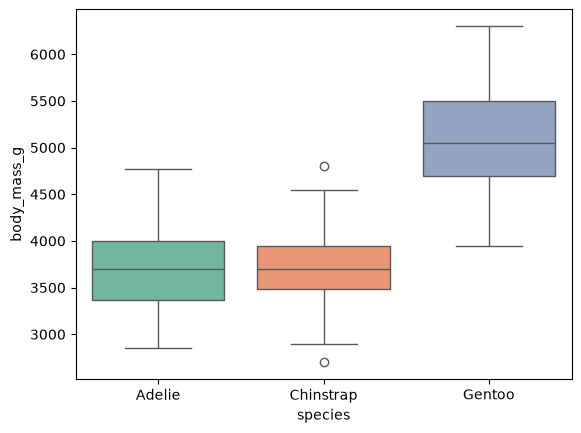

In [24]:
sns.boxplot(data=df,x="species",y='body_mass_g',hue="species", palette="Set2", legend=False)

### Interpretation
Gentoo penguins are clearly heavier, with a higher median and box position than Adelie and Chinstrap. <br/>
Check for outlier dots beyond the whiskers — if you see any, those are candidate unusual penguins worth investigating.  <br/>
Notice how Adelie and Chinstrap overlap a lot — their body masses aren't as easily distinguished. <br/>


## 5. KDE (Kernel Density Estimate)

**What it is:** A smoothed curve estimating the underlying probability density of your data —
think of it as a smoothed, continuous version of a histogram.

**Why we use it:** It reveals the actual **shape** of a distribution — is it unimodal (one peak),
bimodal (two peaks), skewed, etc. — details a boxplot can't show.

**How to read it:** Peaks = where data is concentrated. Width = spread. Multiple bumps = possible
subgroups mixed together (e.g., different species!).

**Tip:** The "smoothness" is controlled by a bandwidth parameter — too high oversmooths and hides
real structure; too low creates fake bumpy noise. Seaborn picks a reasonable default automatically.

<Axes: xlabel='body_mass_g', ylabel='Density'>

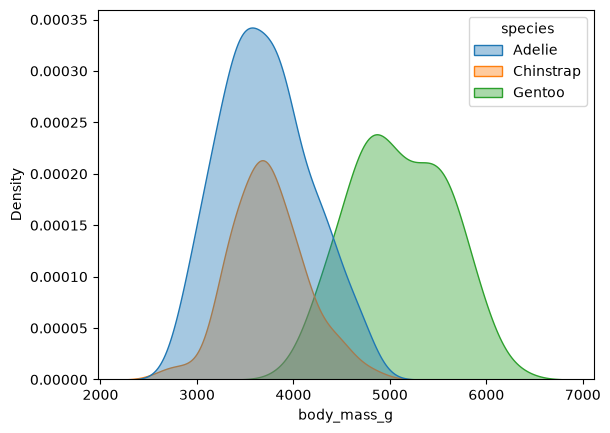

In [21]:
sns.kdeplot(data=df,x='body_mass_g', hue="species", fill=True, alpha=0.4)

### Interpretation
Notice how the *overall* body mass distribution (if you ignored species) would look bimodal or
lumpy — that's because we're actually mixing three separate, fairly normal-looking distributions!
This is exactly what the boxplot couldn't show you. Gentoo's curve sits clearly to the right (heavier),
with little overlap with the other two.

## 6. Violin Plot

**What it is:** A hybrid of a KDE and a boxplot — the "violin" shape is a mirrored density curve,
often with a mini boxplot or median marker inside.

**Why we use it:** Best of both worlds — compare distribution **shape** (like KDE) *and* summary
stats (like boxplot) across multiple groups side by side.

**How to read it:** Width at any height = density of data there. Wider sections = more common
values. Look for asymmetry, multiple bumps, or differing widths between groups.

**Tip:** Violin plots can look "fancy" but are harder to read at a glance for non-technical audiences.
Use them when shape comparison matters; use boxplots for simpler communication.

<Axes: xlabel='species', ylabel='body_mass_g'>

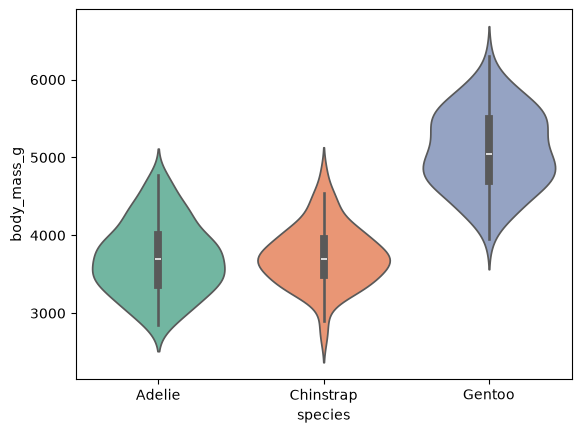

In [23]:
sns.violinplot(data=df,x='species' ,y='body_mass_g',hue="species", palette="Set2", legend=False)

### Interpretation
You can now see both the spread (violin width) and the central tendency (line/dot inside) at once.
Gentoo's violin is noticeably wider and shifted higher — more variable *and* heavier. If any violin
looks lumpy (multiple bulges), that hints at further hidden subgroups (e.g., sex differences within species).

## 7. QQ Plot (Quantile-Quantile Plot)

**What it is:** A scatter plot comparing your data's quantiles against the quantiles of a theoretical
distribution (usually normal). If your data matches that distribution, points fall on a straight
diagonal line.

**Why we use it:** It's the go-to visual check for "is my data approximately normal?" — more precise
than eyeballing a histogram, and used before applying tests/models that assume normality.

**How to read it:**
- Points hug the diagonal line → data is close to normal
- Points curve away at the ends (S-shape) → heavier or lighter tails than normal (relates to kurtosis!)
- Points systematically bow above/below the line → skewed data

**Tip:** Don't expect a *perfect* line with real data — some wiggle is normal. Focus on the tails
(the ends), where deviations matter most for statistical assumptions.

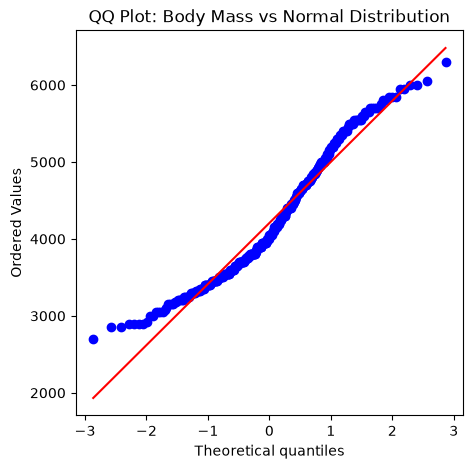

In [31]:
fig = plt.figure(figsize=(5, 5))
stats.probplot(df["body_mass_g"], dist="norm", plot=plt)  # compares data quantiles to normal quantiles
plt.title("QQ Plot: Body Mass vs Normal Distribution")
plt.show()

### Interpretation
Points mostly follow the red line in the middle but may drift away at the ends — this reflects the
mild skew and multi-species mixing we saw earlier in the KDE plot. This is a good reminder:
QQ plots on *unmixed* data (e.g., within a single species) usually look much straighter — try it
yourself in the practice questions below!

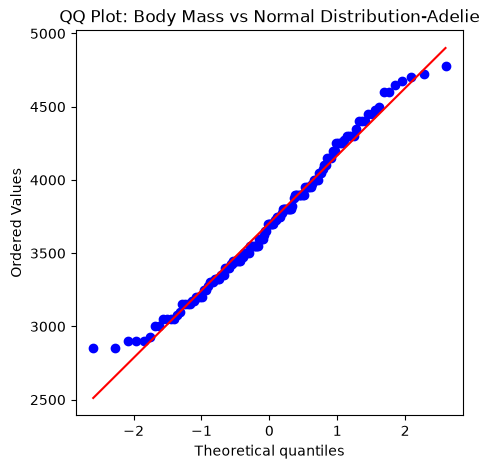

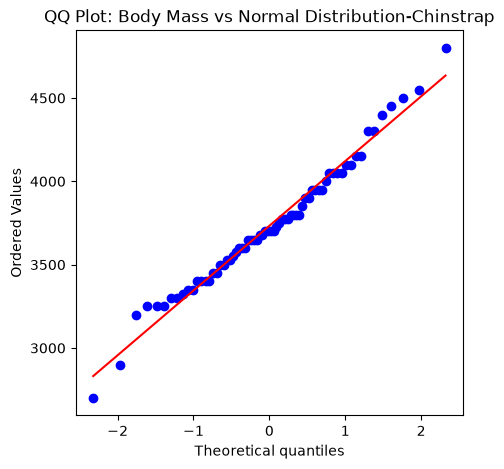

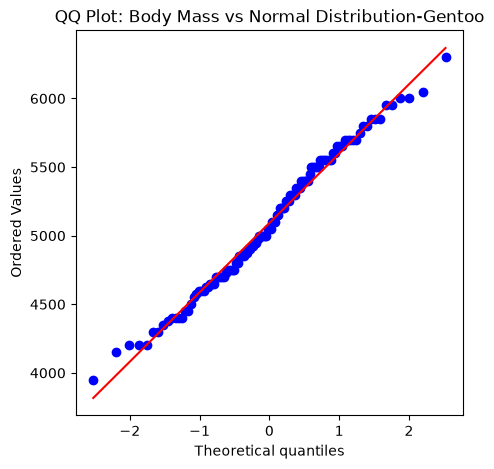

In [42]:
for species,weights in df.groupby("species")["body_mass_g"]:
    fig = plt.figure(figsize=(5, 5))
    stats.probplot(weights, dist="norm", plot=plt)  # compares data quantiles to normal quantiles
    plt.title(f"QQ Plot: Body Mass vs Normal Distribution-{species}")
    plt.show()
    

## 8. 5-Minute Cheat Sheet

| Concept | One-liner | Key Question It Answers |
|---|---|---|
| **Quantile** | Cut points dividing data (e.g., median, quartiles) | "Where does this value rank?" |
| **Skewness** | Left/right asymmetry of the distribution | "Is one tail longer than the other?" |
| **Kurtosis** | Tail heaviness vs. normal distribution | "How outlier-prone is this data?" |
| **Boxplot** | Median, quartiles, whiskers, outliers | "What's the 5-number summary, and are there outliers?" |
| **KDE** | Smoothed density curve | "What's the actual shape of the distribution?" |
| **Violin Plot** | KDE + boxplot combined, by group | "How do shape AND summary stats compare across groups?" |
| **QQ Plot** | Data quantiles vs. theoretical (normal) quantiles | "Is my data approximately normally distributed?" |

**Rule of thumb workflow:** Start with quantiles/boxplot for a quick summary → use KDE/violin to see
shape and compare groups → use skew/kurtosis to quantify shape → use QQ plot to check normality
before running parametric tests.